In [7]:
!pip install -q dtreeviz graphviz cairosvg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 2.5 MB/s eta 0:00:00


TITANIC SURVIVAL PREDICTION PROJECT

1. Loading the dataset...
Dataset loaded successfully.
Dataset shape: (891, 12)

First 5 rows of the dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON

KeyboardInterrupt: 

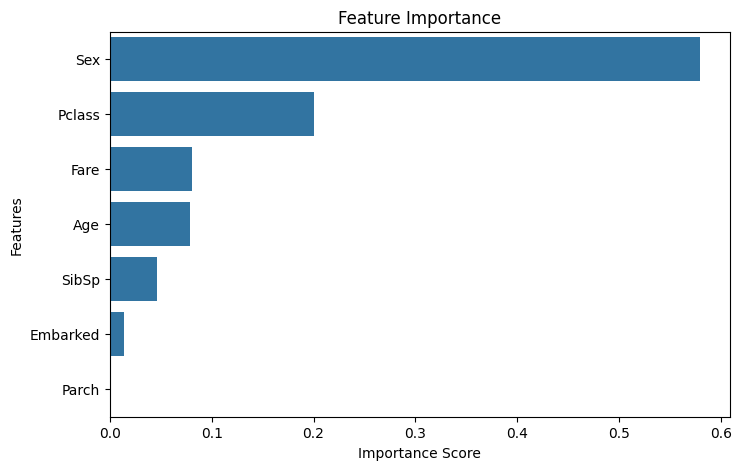

In [9]:
# Titanic Survival Prediction using Decision Tree
# CSE3267 Data Mining Project
# Decision Tree Visualization with dtreeviz saved as PNG

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from dtreeviz import model as dtreeviz_model
import cairosvg

matplotlib.rcParams["font.family"] = "DejaVu Sans"


print("=" * 60)
print("TITANIC SURVIVAL PREDICTION PROJECT")
print("=" * 60)


# ---------------------------------------------------------
# 1. Load the dataset
# ---------------------------------------------------------

print("\n1. Loading the dataset...")

df = pd.read_csv("train.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nDataset information:")
print(df.info())

print("\nBasic statistical description:")
print(df.describe())

print("\nMissing values before preprocessing:")
print(df.isnull().sum())


# ---------------------------------------------------------
# 2. Exploratory Data Analysis
# ---------------------------------------------------------

print("\n2. Creating Exploratory Data Analysis plots...")

# Plot 1: Survival Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Distribution")
plt.xlabel("Survived: 0 = Died, 1 = Survived")
plt.ylabel("Number of Passengers")
plt.savefig("survival_distribution.png", bbox_inches="tight", dpi=300)
plt.close()

# Plot 2: Survival by Sex
plt.figure(figsize=(6, 4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Died", "Survived"])
plt.savefig("survival_by_sex.png", bbox_inches="tight", dpi=300)
plt.close()

# Plot 3: Survival by Passenger Class
plt.figure(figsize=(6, 4))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Died", "Survived"])
plt.savefig("survival_by_class.png", bbox_inches="tight", dpi=300)
plt.close()

# Plot 4: Age Distribution
plt.figure(figsize=(7, 4))
sns.histplot(df["Age"].dropna(), bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.savefig("age_distribution.png", bbox_inches="tight", dpi=300)
plt.close()

# Plot 5: Fare Distribution
plt.figure(figsize=(7, 4))
sns.histplot(df["Fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.savefig("fare_distribution.png", bbox_inches="tight", dpi=300)
plt.close()

print("EDA plots saved successfully.")


# ---------------------------------------------------------
# 3. Data Preprocessing
# ---------------------------------------------------------

print("\n3. Starting data preprocessing...")

df_processed = df.copy()

# Fill missing Age values with median age
age_median = df_processed["Age"].median()
df_processed["Age"] = df_processed["Age"].fillna(age_median)

# Fill missing Embarked values with the most frequent port
embarked_mode = df_processed["Embarked"].mode()[0]
df_processed["Embarked"] = df_processed["Embarked"].fillna(embarked_mode)

# Encode categorical variables manually
# Same as in the presentation:
# male = 0, female = 1
# S = 0, C = 1, Q = 2
df_processed["Sex"] = df_processed["Sex"].map({
    "male": 0,
    "female": 1
})

df_processed["Embarked"] = df_processed["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

# Drop columns that are not useful for this basic Decision Tree model
df_processed = df_processed.drop(
    ["PassengerId", "Name", "Ticket", "Cabin"],
    axis=1
)

print("\nMissing values after preprocessing:")
print(df_processed.isnull().sum())

print("\nProcessed dataset preview:")
print(df_processed.head())

df_processed.to_csv("titanic_cleaned.csv", index=False)
print("\nCleaned dataset saved as titanic_cleaned.csv")


# ---------------------------------------------------------
# 4. Feature and Target Selection
# ---------------------------------------------------------

print("\n4. Splitting data into features and target...")

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

X = df_processed[features]
y = df_processed["Survived"]

print("Features used for training:")
print(features)

print("\nTarget variable:")
print("Survived")


# ---------------------------------------------------------
# 5. Train-Test Split
# ---------------------------------------------------------

print("\n5. Splitting the dataset into training and testing sets...")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])


# ---------------------------------------------------------
# 6. Model Training
# ---------------------------------------------------------

print("\n6. Training Decision Tree model...")

tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train, y_train)

print("Model training completed successfully.")


# ---------------------------------------------------------
# 7. Model Evaluation
# ---------------------------------------------------------

print("\n7. Evaluating the model...")

y_pred = tree_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-score:  {f1 * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Died", "Survived"]
))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ---------------------------------------------------------
# 8. Save Evaluation Results to Text File
# ---------------------------------------------------------

print("\n8. Saving evaluation results...")

with open("model_results.txt", "w", encoding="utf-8") as file:
    file.write("Titanic Survival Prediction using Decision Tree\n")
    file.write("=" * 50 + "\n\n")
    file.write(f"Dataset shape: {df.shape}\n")
    file.write(f"Training set size: {X_train.shape[0]}\n")
    file.write(f"Testing set size: {X_test.shape[0]}\n\n")

    file.write("Model Evaluation Metrics:\n")
    file.write(f"Accuracy:  {accuracy * 100:.2f}%\n")
    file.write(f"Precision: {precision * 100:.2f}%\n")
    file.write(f"Recall:    {recall * 100:.2f}%\n")
    file.write(f"F1-score:  {f1 * 100:.2f}%\n\n")

    file.write("Confusion Matrix:\n")
    file.write(str(cm))
    file.write("\n\n")

    file.write("Classification Report:\n")
    file.write(classification_report(
        y_test,
        y_pred,
        target_names=["Died", "Survived"]
    ))

print("Model results saved as model_results.txt")


# ---------------------------------------------------------
# 9. Model Visualization
# ---------------------------------------------------------

print("\n9. Creating model visualization plots...")

# Plot 6: Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Died", "Survived"],
    yticklabels=["Died", "Survived"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png", bbox_inches="tight", dpi=300)
plt.close()

# Plot 7: Feature Importance
feature_importance = pd.Series(
    tree_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.savefig("feature_importance.png", bbox_inches="tight", dpi=300)
plt.close()

print("\nFeature Importance Values:")
print(feature_importance)

# Plot 8: Standard Decision Tree Visualization
plt.figure(figsize=(22, 12))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization")
plt.savefig("decision_tree.png", bbox_inches="tight", dpi=300)
plt.close()

print("Standard decision_tree.png saved successfully.")


# ---------------------------------------------------------
# 10. Beautiful Decision Tree Visualization with dtreeviz
# ---------------------------------------------------------

print("\n10. Creating beautiful Decision Tree visualization with dtreeviz...")

viz_model = dtreeviz_model(
    tree_model,
    X_train=X_train,
    y_train=y_train,
    feature_names=features,
    target_name="Survived",
    class_names=["Died", "Survived"]
)

v = viz_model.view(
    scale=1.1,
    orientation="LR"
)

# First save as SVG
v.save("titanic_dtreeviz.svg")
print("dtreeviz SVG saved as titanic_dtreeviz.svg")

# Then convert SVG to PNG
cairosvg.svg2png(
    url="titanic_dtreeviz.svg",
    write_to="titanic_dtreeviz.png",
    output_width=3000
)

print("dtreeviz PNG saved as titanic_dtreeviz.png")


# ---------------------------------------------------------
# 11. Final Summary
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nGenerated files:")
print("1. survival_distribution.png")
print("2. survival_by_sex.png")
print("3. survival_by_class.png")
print("4. age_distribution.png")
print("5. fare_distribution.png")
print("6. confusion_matrix.png")
print("7. feature_importance.png")
print("8. decision_tree.png")
print("9. titanic_dtreeviz.svg")
print("10. titanic_dtreeviz.png")
print("11. titanic_cleaned.csv")
print("12. model_results.txt")

print("\nFinal model accuracy:", f"{accuracy * 100:.2f}%")
print("The most important feature was:", feature_importance.index[0])

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(26, 14))

plot_tree(
    tree_model,
    feature_names=features,
    class_names=["Died", "Survived"],
    filled=True,
    rounded=True,
    fontsize=11,
    impurity=True,
    proportion=False
)

plt.title(
    "Decision Tree Visualization",
    fontsize=22,
    fontweight="bold",
    pad=20
)

plt.savefig(
    "decision_tree_presentation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Saved as decision_tree_presentation.png")

Saved as decision_tree_presentation.png
